In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv(r"D:\AIML_MSIS\Applied Machine Learning\Lab_programs\Septmber_1\income_data.csv")

In [3]:
df.head()

,Unnamed: 0,income,happiness
0,1,3.862647,2.314489
1,2,4.979381,3.433490
2,3,4.923957,4.599373
3,4,3.214372,2.791114
4,5,7.196409,5.596398


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

Unnamed: 0    0
income        0
happiness     0
dtype: int64

In [6]:
x = df[["income"]]
x

,income
0,3.862647
1,4.979381
2,4.923957
3,3.214372
4,7.196409
...,...
493,5.249209
494,3.471799
495,6.087610
496,3.440847


In [7]:
y = df["happiness"]
y

0      2.314489
1      3.433490
2      4.599373
3      2.791114
4      5.596398
         ...   
493    4.568705
494    2.535002
495    4.397451
496    2.070664
497    3.710193
Name: happiness, Length: 498, dtype: float64

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [12]:
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [13]:
print("Intercept : ", model.intercept_)
print("Slope : ", model.coef_[0])

Intercept :  0.14170387227353531
Slope :  0.7247687016076183


In [14]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))

MAE       :  0.6269683431894553
MSE       :  0.590146394343082
RMSE      :  0.768209863476825
R-squared :  0.6662585264303965


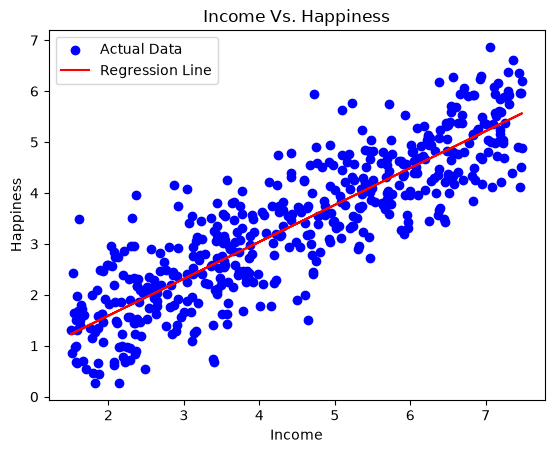

In [19]:
plt.scatter(x, y, color = "blue", label = "Actual Data")
plt.plot(x, model.predict(x), color = "red", label = "Regression Line")

plt.xlabel("Income")
plt.ylabel("Happiness")
plt.title("Income Vs. Happiness")
#plt.grid(True)
plt.legend()
plt.show()


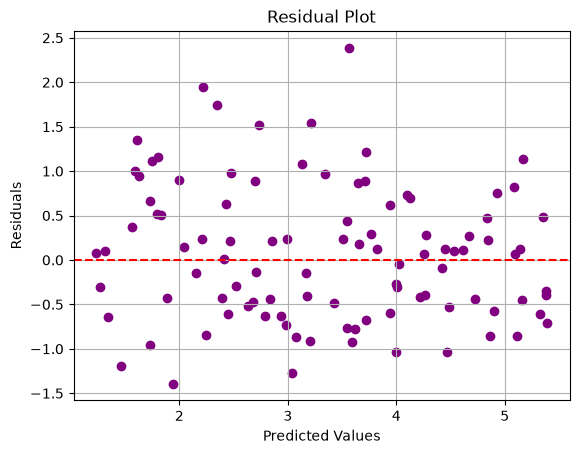

In [22]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, color = "purple")
plt.axhline(y = 0, color = "red", linestyle = "--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()